# Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import os

# Data Loading

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data_dir = "/content/drive/MyDrive/Hackathon - Data"
os.listdir(data_dir)

['city_daily_context.csv',
 'stations.csv',
 'swap_events.csv',
 'batteries.csv',
 'support_tickets.csv',
 'fleet_partners.csv',
 'station_hourly_status.csv',
 'riders.csv']

In [4]:
swaps = pd.read_csv(f"{data_dir}/swap_events.csv", low_memory=False)
telemetry = pd.read_csv(f"{data_dir}/station_hourly_status.csv", low_memory=False)
riders = pd.read_csv(f"{data_dir}/riders.csv")
batteries = pd.read_csv(f"{data_dir}/batteries.csv")
tickets = pd.read_csv(f"{data_dir}/support_tickets.csv")
stations = pd.read_csv(f"{data_dir}/stations.csv")
city_context = pd.read_csv(f"{data_dir}/city_daily_context.csv")
partners = pd.read_csv(f"{data_dir}/fleet_partners.csv")

# DATA QUALITY CHECK

In [5]:
quality_summary = []

datasets = {
    "support_tickets": tickets,
    "station_hourly_status": telemetry,
    "riders": riders,
    "city_daily_context": city_context,
    "fleet_partners": partners,
    "stations": stations,
    "swaps": swaps,
    "batteries": batteries
}

for name, df in datasets.items():
    quality_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isna().sum().sum()),
        "Missing %": round(df.isna().sum().sum() / df.size * 100, 2)
    })

quality_df = pd.DataFrame(quality_summary)

display(quality_df)

,Dataset,Rows,Columns,Missing Values,Missing %
0,support_tickets,44000,12,50445,9.55
1,station_hourly_status,1487712,14,896880,4.31
2,riders,20000,12,12837,5.35
3,city_daily_context,3282,12,3172,8.05
4,fleet_partners,12,12,22,15.28
5,stations,152,22,293,8.76
6,swaps,3877013,22,1037944,1.22
7,batteries,6500,13,10124,11.98


# Data Cleaning

In [6]:
stations = stations[~stations['station_id'].str.startswith('STN-TST')]
city_map = {'Bangalore': 'Bengaluru', 'Bengluru': 'Bengaluru', 'Bombay': 'Mumbai'}
riders['home_city'] = riders['home_city'].replace(city_map)

swaps['event_ts'] = pd.to_datetime(swaps['event_ts'])
mask = (swaps['station_firmware'] == 'v3.2.0') & (swaps['event_ts'] >= '2025-03-10') & (swaps['event_ts'] <= '2025-04-14')
swaps.loc[mask, 'event_ts'] = swaps.loc[mask, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)

swaps['soc_out_pct'] = swaps['soc_out_pct'].clip(upper=100)
swaps.loc[swaps['km_since_last_swap'] < 0, 'km_since_last_swap'] = np.nan
swaps = swaps.drop_duplicates(subset=['rider_id', 'station_id', 'battery_in_id', 'battery_out_id'])


print("Swaps shape:", swaps.shape)
print("Stations count:", len(stations))
print("Riders count:", len(riders))

Swaps shape: (3866372, 22)
Stations count: 150
Riders count: 20000


# Network Performace over time

/tmp/ipykernel_15142/179442009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps['event_month'] = swaps['event_ts'].dt.to_period('M')


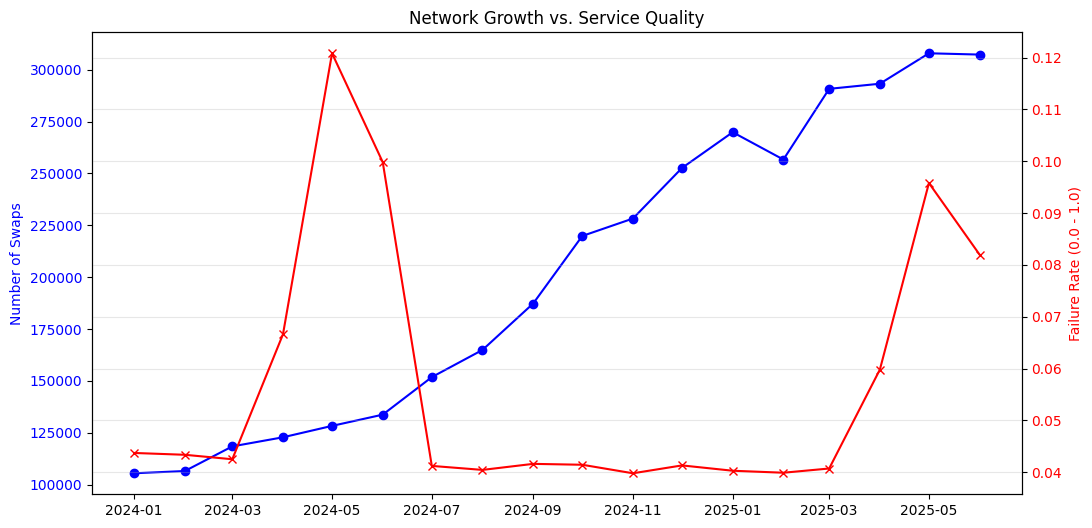

In [7]:
swaps['event_month'] = swaps['event_ts'].dt.to_period('M')
monthly_stats = swaps.groupby('event_month').agg(
    total_attempts=('event_id', 'count'),
    completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum()),
    total_revenue=('amount_charged_inr', 'sum')
).reset_index()
monthly_stats['failure_rate'] = 1 - (monthly_stats['completed_swaps'] / monthly_stats['total_attempts'])
monthly_stats['rev_per_swap'] = monthly_stats['total_revenue'] / monthly_stats['completed_swaps']
monthly_stats['event_month'] = monthly_stats['event_month'].dt.to_timestamp()



fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_stats['event_month'], monthly_stats['completed_swaps'], color='blue', marker='o', label='Completed Swaps')
ax1.set_ylabel('Number of Swaps', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(monthly_stats['event_month'], monthly_stats['failure_rate'], color='red', marker='x', label='Failure Rate')
ax2.set_ylabel('Failure Rate (0.0 - 1.0)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Network Growth vs. Service Quality')
plt.grid(True, alpha=0.3)
plt.show()


# Proving the "Heat Hypothesis"

/tmp/ipykernel_15142/2116628619.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_analysis = swaps_temp.groupby('temp_bucket').agg(


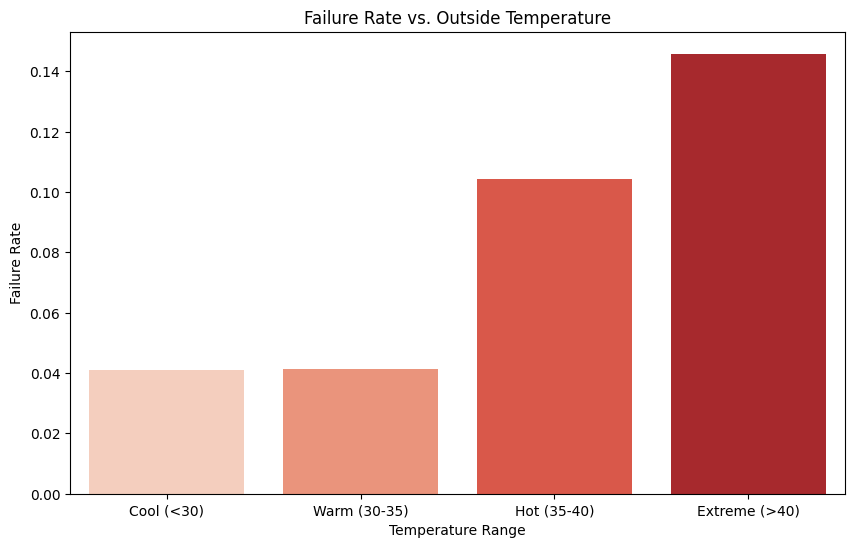

In [8]:
swaps_with_city = swaps.merge(stations[['station_id', 'city']], on='station_id', how='left')

swaps_with_city['date'] = swaps_with_city['event_ts'].dt.date
city_context['date'] = pd.to_datetime(city_context['date']).dt.date

swaps_temp = swaps_with_city.merge(
    city_context[['city', 'date', 'max_temp_c']],
    on=['city', 'date'],
    how='left'
)

bins = [0, 30, 35, 40, 60]
labels = ['Cool (<30)', 'Warm (30-35)', 'Hot (35-40)', 'Extreme (>40)']
swaps_temp['temp_bucket'] = pd.cut(swaps_temp['max_temp_c'], bins=bins, labels=labels)

temp_analysis = swaps_temp.groupby('temp_bucket').agg(
    total_attempts=('event_id', 'count'),
    completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum())
).reset_index()

temp_analysis['failure_rate'] = 1 - (temp_analysis['completed_swaps'] / temp_analysis['total_attempts'])


plt.figure(figsize=(10, 6))
sns.barplot(data=temp_analysis, x='temp_bucket', y='failure_rate', hue='temp_bucket', palette='Reds', legend=False)
plt.title('Failure Rate vs. Outside Temperature')
plt.ylabel('Failure Rate')
plt.xlabel('Temperature Range')
plt.show()


# Do Failures Lead to Churn?

   Is Churned  Avg Failures Experienced
0       False                 12.995468
1        True                  7.996567


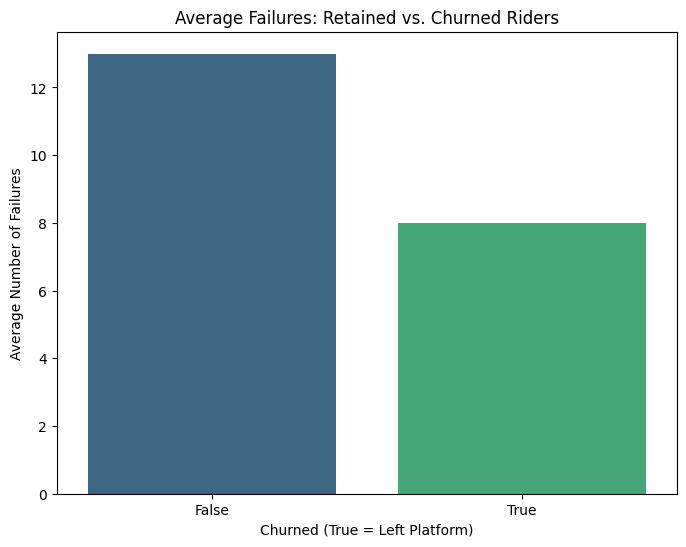

In [9]:
last_date = swaps['event_ts'].max()
rider_last_swap = swaps.groupby('rider_id')['event_ts'].max()
riders = riders.merge(rider_last_swap.rename('last_swap_date'), on='rider_id', how='left')
riders['is_churned'] = (last_date - riders['last_swap_date']).dt.days > 30


failure_counts = swaps[swaps['event_type'] != 'swap_completed'].groupby('rider_id').size().reset_index(name='total_failures')


churn_analysis = riders.merge(failure_counts, on='rider_id', how='left').fillna(0)


churn_comparison = churn_analysis.groupby('is_churned')['total_failures'].mean().reset_index()
churn_comparison.columns = ['Is Churned', 'Avg Failures Experienced']

print(churn_comparison)

plt.figure(figsize=(8, 6))
sns.barplot(data=churn_comparison, x='Is Churned', y='Avg Failures Experienced', hue='Is Churned', palette='viridis', legend=False)
plt.title('Average Failures: Retained vs. Churned Riders')
plt.ylabel('Average Number of Failures')
plt.xlabel('Churned (True = Left Platform)')
plt.show()


# Power User Effect

   Is Churned  Avg Total Swaps
0       False       224.203856
1        True       145.655392


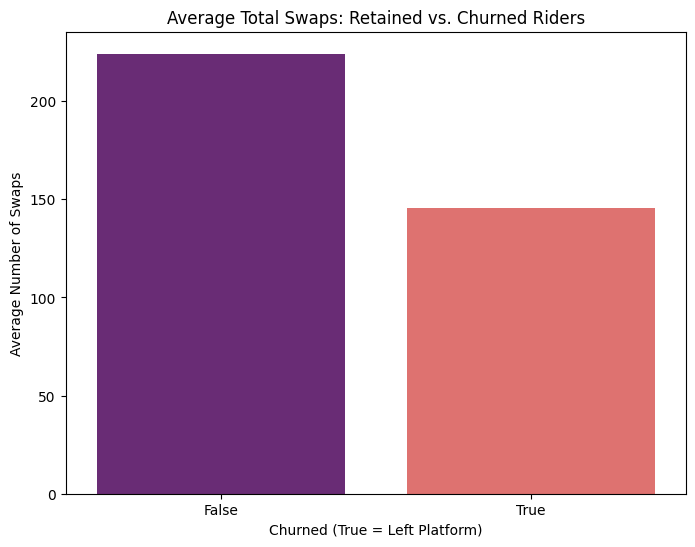

In [10]:
rider_volume = swaps.groupby('rider_id').size().reset_index(name='total_swaps')

volume_analysis = riders.merge(rider_volume, on='rider_id', how='left').fillna(0)

volume_comparison = volume_analysis.groupby('is_churned')['total_swaps'].mean().reset_index()
volume_comparison.columns = ['Is Churned', 'Avg Total Swaps']

print(volume_comparison)

plt.figure(figsize=(8, 6))
sns.barplot(data=volume_comparison, x='Is Churned', y='Avg Total Swaps',hue = "Is Churned", palette='magma',legend=False)
plt.title('Average Total Swaps: Retained vs. Churned Riders')
plt.ylabel('Average Number of Swaps')
plt.xlabel('Churned (True = Left Platform)')
plt.show()


# Partner Profitability

   partner_name  avg_margin  total_swaps  avg_revenue
3      HaulKing   59.593099        60256    90.377914
0      CargoTuk   58.664376       148512    89.773408
1   DabbaXpress   45.550527        98866    60.215071
10  UrbanErrand   45.210679        88428    60.185549
8     RideMitra   44.777055       127364    59.434852
7     QuickCart   44.121478       137405    58.674463
2      FeastFly   43.814129       558283    58.565186
4   LastMileHub   42.032129        86655    57.488535
9    Swiggle Go   40.940016       255868    56.032175
5     MetroMove   40.630955        87917    55.989169
6    ParcelNest   38.384552       318432    53.742647
11      ZipDrop   32.928461       590186    49.162684


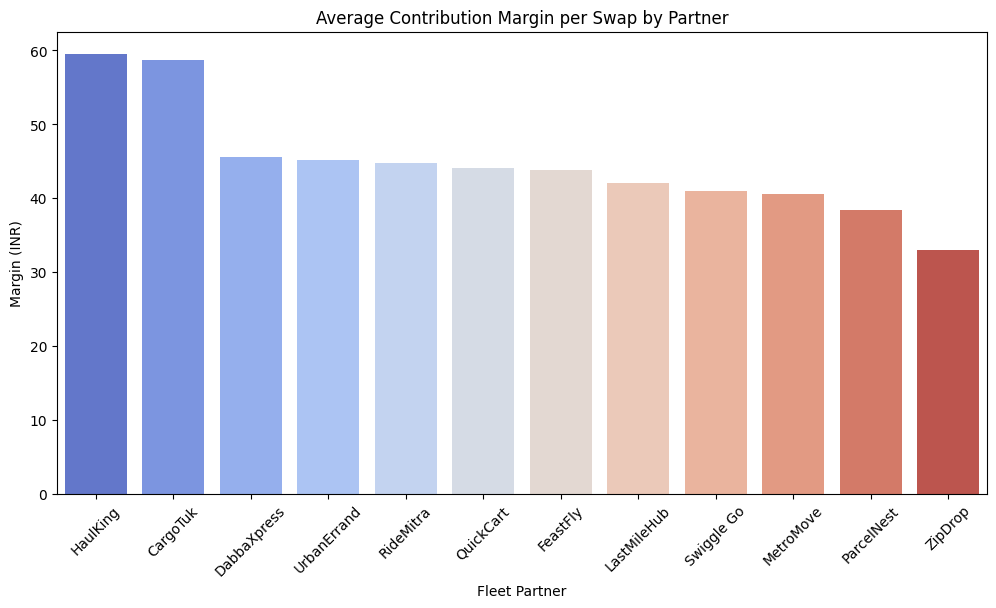

In [11]:
swaps_cost = swaps.merge(stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')
swaps_cost['energy_cost'] = swaps_cost['energy_to_recharge_kwh'] * swaps_cost['grid_tariff_inr_kwh']
swaps_cost['margin'] = swaps_cost['amount_charged_inr'] - swaps_cost['energy_cost']
partner_margins = swaps_cost.merge(riders[['rider_id', 'partner_id']], on='rider_id', how='left')
partner_margins = partner_margins.merge(partners[['partner_id', 'partner_name', 'partner_segment']], on='partner_id', how='left')

partner_analysis = partner_margins.groupby('partner_name').agg(
    avg_margin=('margin', 'mean'),
    total_swaps=('event_id', 'count'),
    avg_revenue=('amount_charged_inr', 'mean')
).reset_index()
partner_analysis = partner_analysis.sort_values('avg_margin', ascending=False)
print(partner_analysis)

plt.figure(figsize=(12, 6))
sns.barplot(data=partner_analysis, x='partner_name', y='avg_margin', hue='partner_name', palette='coolwarm', legend=False)
plt.xticks(rotation=45)
plt.title('Average Contribution Margin per Swap by Partner')
plt.ylabel('Margin (INR)')
plt.xlabel('Fleet Partner')
plt.show()

# Battery Supplier Performance

  supplier  avg_degradation  total_batteries  avg_current_soh
2    Kyron        35.457692             1638        63.747436
1  Cellora        18.254740             3555        80.929030
0   Amptek        18.189212             1307        81.005203


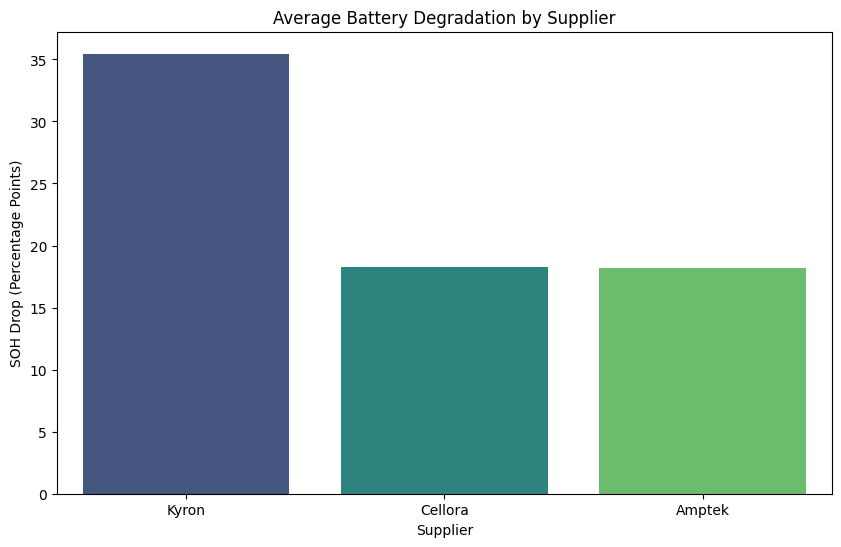

In [12]:
batteries['degradation'] = batteries['initial_soh_pct'] - batteries['current_soh_pct']

supplier_analysis = batteries.groupby('supplier').agg(
    avg_degradation=('degradation', 'mean'),
    total_batteries=('battery_id', 'count'),
    avg_current_soh=('current_soh_pct', 'mean')
).reset_index()

supplier_analysis = supplier_analysis.sort_values('avg_degradation', ascending=False)

print(supplier_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(data=supplier_analysis, x='supplier', y='avg_degradation', hue='supplier', palette='viridis', legend=False)
plt.title('Average Battery Degradation by Supplier')
plt.ylabel('SOH Drop (Percentage Points)')
plt.xlabel('Supplier')
plt.show()


SWAP EVENTS

In [13]:
swaps["event_type"].value_counts()

,count
event_type,
swap_completed,3645774
failed_no_charged_battery,134095
abandoned_queue,68376
cancelled_by_rider,10663
failed_system_error,7464


In [14]:
swaps["event_ts"]=pd.to_datetime(swaps["event_ts"])
swaps["month"]=swaps["event_ts"].dt.to_period("M")
swaps.groupby("month").size()

/tmp/ipykernel_15142/3334073777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["event_ts"]=pd.to_datetime(swaps["event_ts"])
/tmp/ipykernel_15142/3334073777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["month"]=swaps["event_ts"].dt.to_period("M")


,0
month,
2024-01,110310
2024-02,111412
2024-03,123700
2024-04,131599
2024-05,145962
2024-06,148572
2024-07,158348
2024-08,171880
2024-09,195431


PLOTTING TO CHECK THE SWAP ACTIVITY FLUCTUATION OVER 18-MONTH PERIOD

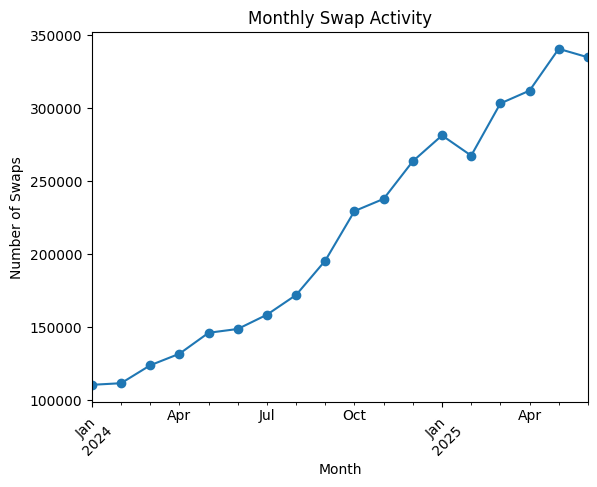

In [15]:
monthly_swaps=swaps.groupby("month").size()
monthly_swaps.plot(kind="line", marker="o")
plt.title("Monthly Swap Activity")
plt.xlabel("Month")
plt.ylabel("Number of Swaps")
plt.xticks(rotation=45)
plt.show()

In [16]:
swaps["event_type"].value_counts()

,count
event_type,
swap_completed,3645774
failed_no_charged_battery,134095
abandoned_queue,68376
cancelled_by_rider,10663
failed_system_error,7464


In [17]:
print(swaps.columns)

Index(['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type',
       'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id',
       'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct',
       'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr',
       'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh',
       'station_firmware', 'sync_mode', 'event_month', 'month'],
      dtype='object')


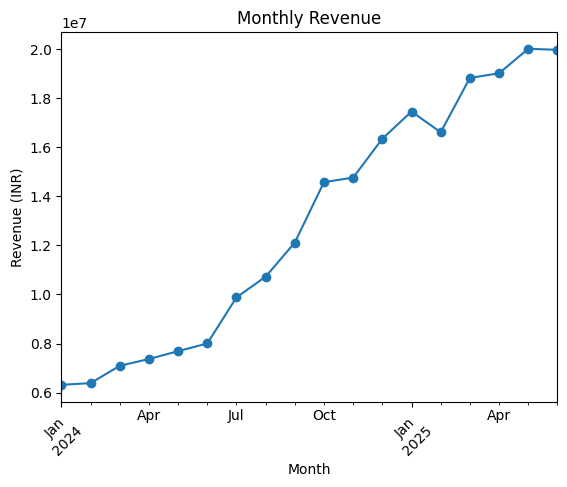

In [18]:
monthly_revenue =swaps.groupby("month")["amount_charged_inr"].sum()
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.show()

In [19]:
event_counts = swaps["event_type"].value_counts()
print(event_counts)

event_type
swap_completed               3645774
failed_no_charged_battery     134095
abandoned_queue                68376
cancelled_by_rider             10663
failed_system_error             7464
Name: count, dtype: int64


In [20]:
total_swaps =len(swaps)

failed_swaps=len(swaps[swaps["event_type"]!="swap_completed"])
failure_rate =failed_swaps/total_swaps*100
print("total attempts:",total_swaps)
print("failed /unsuccessful attempts:",failed_swaps)
print("failure rate:",failure_rate)

total attempts: 3866372
failed /unsuccessful attempts: 220598
failure rate: 5.705555492332347


In [21]:
swaps["queue_wait_sec"].mean()

np.float64(243.47238651635178)

In [22]:
swaps.groupby("event_type")["queue_wait_sec"].mean()

,queue_wait_sec
event_type,
abandoned_queue,702.549286
cancelled_by_rider,44.743130
failed_no_charged_battery,29.499512
failed_system_error,44.172160
swap_completed,243.721847


In [23]:
event_counts = swaps["event_type"].value_counts()
event_counts

,count
event_type,
swap_completed,3645774
failed_no_charged_battery,134095
abandoned_queue,68376
cancelled_by_rider,10663
failed_system_error,7464


In [24]:
failed = swaps[swaps["event_type"] !="swap completed"]
failed["station_id"].value_counts().head(10)

,count
station_id,
STN-BLR-019,57819
STN-BLR-004,51928
STN-HYD-072,51599
STN-HYD-070,49527
STN-DEL-043,49430
STN-JAI-138,48768
STN-DEL-050,46899
STN-PUN-096,46040
STN-HYD-065,45856


In [25]:
print("total rows:",len(swaps))
print("event types:")
print(swaps["event_type"].value_counts())
print(swaps.shape)

total rows: 3866372
event types:
event_type
swap_completed               3645774
failed_no_charged_battery     134095
abandoned_queue                68376
cancelled_by_rider             10663
failed_system_error             7464
Name: count, dtype: int64
(3866372, 24)


TOTAL REVENUE

In [26]:
total_revenue = swaps["amount_charged_inr"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 233123168.14999995


In [27]:
average_revenue = swaps["amount_charged_inr"].mean()
print("average revenue per attempt:", average_revenue)


average revenue per attempt: 60.29506942166971


In [28]:
monthly_revenue = swaps.groupby("month")["amount_charged_inr"].sum()
monthly_revenue

,amount_charged_inr
month,
2024-01,6318910.20
2024-02,6387614.80
2024-03,7093617.00
2024-04,7370106.80
2024-05,7689506.00
2024-06,8003275.60
2024-07,9879459.60
2024-08,10724199.85
2024-09,12115152.30


In [29]:
revenue_payment =swaps.groupby("payment_mode")["amount_charged_inr"].sum()
revenue_payment.sort_values(ascending=False)

,amount_charged_inr
payment_mode,
partner_invoice,2.331232e+08


In [30]:
station_swaps = swaps["station_id"].value_counts()
station_swaps.head(10)

,count
station_id,
STN-BLR-019,57819
STN-BLR-004,51928
STN-HYD-072,51599
STN-HYD-070,49527
STN-DEL-043,49430
STN-JAI-138,48768
STN-DEL-050,46899
STN-PUN-096,46040
STN-HYD-065,45856


In [31]:
station_swaps = swaps["station_id"].value_counts()
station_swaps.head(10)

,count
station_id,
STN-BLR-019,57819
STN-BLR-004,51928
STN-HYD-072,51599
STN-HYD-070,49527
STN-DEL-043,49430
STN-JAI-138,48768
STN-DEL-050,46899
STN-PUN-096,46040
STN-HYD-065,45856


In [32]:
city_data = swaps.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left")
city_data["failed"] = city_data["event_type"] != "swap_completed"
city_failure = city_data.groupby("city")["failed"].mean() * 100
city_failure.sort_values(ascending=False)

,failed
city,
Jaipur,7.600504
Delhi NCR,7.099804
Hyderabad,6.425908
Pune,4.727999
Bengaluru,4.282593
Mumbai,4.192554


In [33]:
city_swaps= city_data["city"].value_counts()
city_swaps

,count
city,
Delhi NCR,766824
Bengaluru,761151
Hyderabad,709923
Pune,551396
Mumbai,528890
Jaipur,486323


In [34]:
city_wait =city_data.groupby("city")["queue_wait_sec"].mean()
city_wait.sort_values(ascending=False)

,queue_wait_sec
city,
Jaipur,243.768765
Mumbai,243.764267
Pune,243.526895
Bengaluru,243.415233
Hyderabad,243.311666
Delhi NCR,243.230726


In [35]:
wait_result = city_data.groupby("failed")["queue_wait_sec"].mean()
wait_result

,queue_wait_sec
failed,
False,243.721847
True,239.349604


In [36]:
station_count= swaps["station_id"].value_counts()
station_count.head(10)

,count
station_id,
STN-BLR-019,57819
STN-BLR-004,51928
STN-HYD-072,51599
STN-HYD-070,49527
STN-DEL-043,49430
STN-JAI-138,48768
STN-DEL-050,46899
STN-PUN-096,46040
STN-HYD-065,45856


In [37]:
station_data =swaps.copy()
station_data["failed"] =station_data["event_type"]!="swap_completed"
station_failure =station_data.groupby("station_id")["failed"].mean()*100
station_failure.sort_values(ascending=False).head(10)

,failed
station_id,
STN-DEL-037,8.881739
STN-DEL-048,8.732019
STN-JAI-142,8.518385
STN-JAI-141,8.468611
STN-JAI-137,8.458060
STN-JAI-136,8.449549
STN-DEL-045,8.435759
STN-JAI-139,8.359976
STN-DEL-040,8.358825


In [38]:
station_wait =swaps.groupby("station_id")["queue_wait_sec"].mean()
station_wait.sort_values(ascending=False).head(10)


,queue_wait_sec
station_id,
STN-DEL-062,246.711551
STN-BLR-025,246.654812
STN-JAI-147,246.212010
STN-MUM-127,245.785664
STN-JAI-143,245.595975
STN-PUN-108,245.487350
STN-BLR-008,245.431337
STN-JAI-148,245.281350
STN-DEL-059,245.274752


In [39]:
station_information =stations[["station_id", "city","location_type","charger_generation"]].copy()
station_analysis =station_information.merge(station_failure.rename("failure_rate"),on="station_id",how="left")
station_analysis.sort_values("failure_rate",ascending=False).head(10)

,station_id,city,location_type,charger_generation,failure_rate
36,STN-DEL-037,Delhi NCR,commercial_hub,Gen1,8.881739
47,STN-DEL-048,Delhi NCR,market,Gen1,8.732019
141,STN-JAI-142,Jaipur,commercial_hub,Gen1,8.518385
140,STN-JAI-141,Jaipur,commercial_hub,Gen1,8.468611
136,STN-JAI-137,Jaipur,commercial_hub,Gen1,8.458060
135,STN-JAI-136,Jaipur,transit_hub,Gen1,8.449549
44,STN-DEL-045,Delhi NCR,commercial_hub,Gen1,8.435759
138,STN-JAI-139,Jaipur,commercial_hub,Gen1,8.359976
39,STN-DEL-040,Delhi NCR,market,Gen1,8.358825
137,STN-JAI-138,Jaipur,market,Gen1,8.335384


In [40]:
charger_failure = station_analysis.groupby(
    "charger_generation"
)["failure_rate"].mean()

charger_failure.sort_values(ascending=False)

,failure_rate
charger_generation,
Gen1,6.910634
Gen3,4.710661
Gen2,4.629749


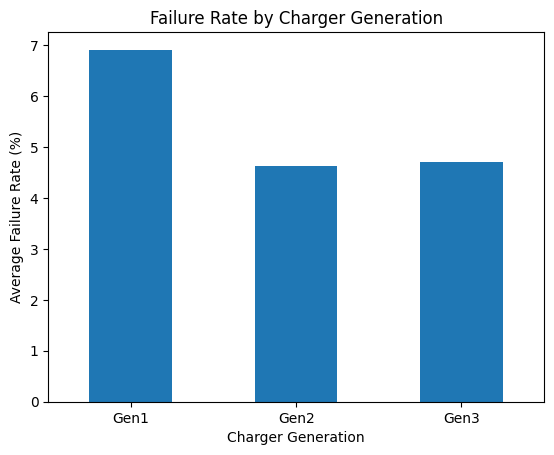

In [41]:
charger_failure.plot(kind="bar")
plt.title("Failure Rate by Charger Generation")
plt.xlabel("Charger Generation")
plt.ylabel("Average Failure Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [42]:
swaps["hour"]= swaps["event_ts"].dt.hour

/tmp/ipykernel_15142/1614193462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["hour"]= swaps["event_ts"].dt.hour


In [43]:
hour_total =swaps.groupby("hour").size()
hour_total

,0
hour,
0,22340
1,22159
2,22327
3,22435
4,25447
5,25218
6,55570
7,55970
8,167073


In [44]:
hour_failed = swaps[swaps["event_type"] != "swap_completed"].groupby("hour").size()
hour_failed

,0
hour,
0,1182
1,1179
2,1195
3,1171
4,1265
5,1290
6,2925
7,2952
8,9067


In [45]:
hour_failure_rate=(hour_failed/ hour_total)*100
hour_failure_rate

,0
hour,
0,5.290958
1,5.320637
2,5.352264
3,5.219523
4,4.971116
5,5.115394
6,5.263631
7,5.274254
8,5.426969


PLOT HOURLY FAILURE RATE

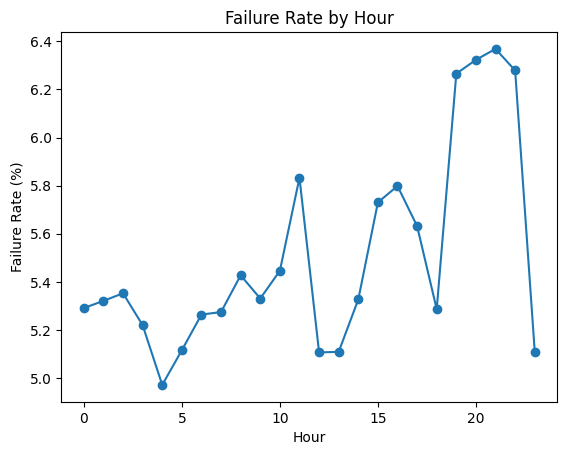

In [46]:
hour_failure_rate.plot(kind="line", marker="o")
plt.title("Failure Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Failure Rate (%)")
plt.show()

In [47]:
hour_failure_rate.sort_values(ascending=False).head(10)

,0
hour,
21,6.368689
20,6.323252
22,6.279253
19,6.265888
11,5.832884
16,5.798504
15,5.730297
17,5.631783
10,5.445771


In [48]:
swaps["day"] = swaps["event_ts"].dt.day_name()

/tmp/ipykernel_15142/1203606385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["day"] = swaps["event_ts"].dt.day_name()


In [49]:
day_total = swaps.groupby("day").size()
day_total


,0
day,
Friday,541650
Monday,544120
Saturday,580110
Sunday,568665
Thursday,547239
Tuesday,540564
Wednesday,544024


In [50]:
day_failed = swaps[swaps["event_type"] != "swap_completed"].groupby("day").size()
day_failed

,0
day,
Friday,30758
Monday,30900
Saturday,33483
Sunday,32403
Thursday,31657
Tuesday,30733
Wednesday,30664


In [51]:
day_failure_rate=(day_failed/day_total)*100
day_failure_rate.sort_values(ascending=False)

,0
day,
Thursday,5.784858
Saturday,5.771836
Sunday,5.698082
Tuesday,5.685358
Monday,5.678894
Friday,5.678575
Wednesday,5.636516


PLOT DAY WISE FAILURE RATES

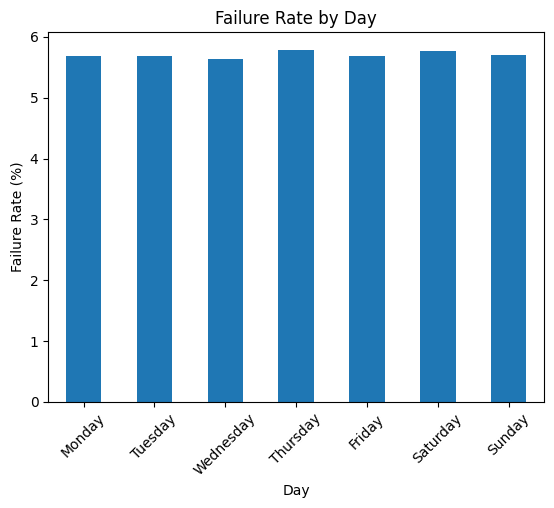

In [52]:
days=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_failure_rate=day_failure_rate.reindex(days)
day_failure_rate.plot(kind="bar")
plt.title("Failure Rate by Day")
plt.xlabel("Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [53]:
tariff_failure = (
swaps["event_type"] != "swap_completed").groupby(swaps["tariff_code"]).mean() * 100
tariff_failure

,event_type
tariff_code,
OFFPEAK,3.997340
PARTNER,5.799532
PEAK,4.234755
STD,5.782990


In [54]:
swaps.groupby("tariff_code")["queue_wait_sec"].mean()

,queue_wait_sec
tariff_code,
OFFPEAK,244.341356
PARTNER,243.514116
PEAK,243.293647
STD,243.373850


In [55]:
failure_by_hour = swaps[swaps["event_type"] != "swap_completed"].groupby(["hour", "event_type"]).size()
failure_by_hour

hour  event_type               
0     abandoned_queue              362
      cancelled_by_rider            56
      failed_no_charged_battery    724
      failed_system_error           40
1     abandoned_queue              381
                                  ... 
22    failed_system_error          326
23    abandoned_queue              409
      cancelled_by_rider            73
      failed_no_charged_battery    750
      failed_system_error           51
Length: 96, dtype: int64

# BATTERY & SOH PERFORMANCE

CHECKING BATTERY DATA

In [56]:
batteries.head()

,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct,degradation
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5,20.4
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5,19.7
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0,12.5
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1,41.4
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6,38.9


BASIC BATTERY SOH

In [57]:
batteries["current_soh_pct"].describe()

,current_soh_pct
count,6500.000000
mean,76.614585
std,8.824758
min,55.400000
25%,78.400000
50%,79.800000
75%,80.800000
max,88.600000


In [58]:
batteries.groupby("supplier")["current_soh_pct"].mean()

,current_soh_pct
supplier,
Amptek,81.005203
Cellora,80.929030
Kyron,63.747436


In [59]:
batteries.groupby("pack_type")["current_soh_pct"].mean()

,current_soh_pct
pack_type,
2W_2.1kWh,75.088909
3W_4.8kWh,85.187576


In [60]:
low_soh = batteries[batteries["current_soh_pct"] < 80]

print("Low SOH batteries:", len(low_soh))

Low SOH batteries: 3502


PLOT SOH DISTRIBUTION

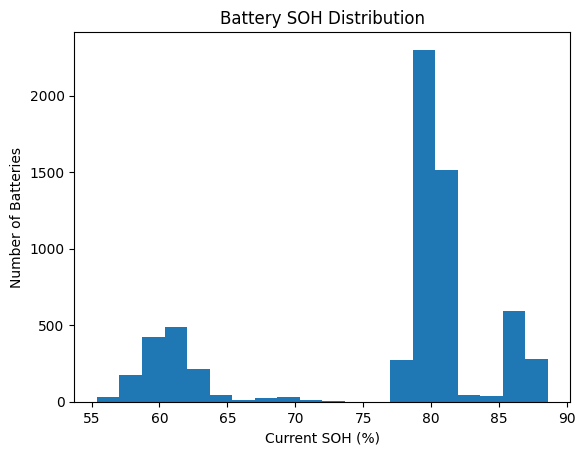

In [61]:
batteries["current_soh_pct"].plot(kind="hist", bins=20)
plt.title("Battery SOH Distribution")
plt.xlabel("Current SOH (%)")
plt.ylabel("Number of Batteries")
plt.show()

BATTERY AGE

In [62]:
batteries["commission_date"] = pd.to_datetime(batteries["commission_date"])
batteries["age_days"] = (pd.Timestamp("2025-06-30") - batteries["commission_date"]).dt.days
batteries["age_days"].head()

,age_days
0,103
1,457
2,781
3,264
4,221


SOH BY BATTERY AGE

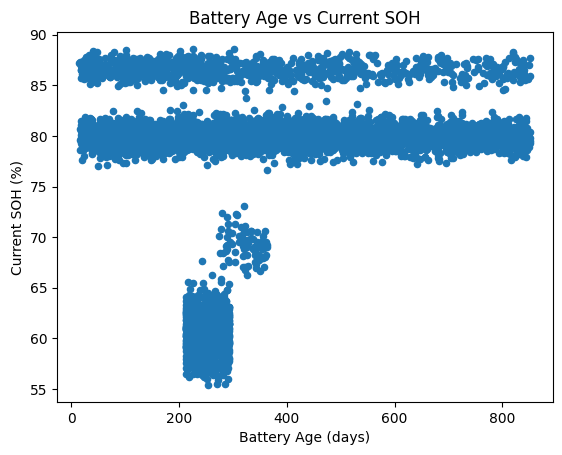

In [63]:
batteries.plot(x="age_days",y="current_soh_pct",kind="scatter")
plt.title("Battery Age vs Current SOH")
plt.xlabel("Battery Age (days)")
plt.ylabel("Current SOH (%)")
plt.show()

In [64]:
supplier_soh = batteries.groupby("supplier")["current_soh_pct"].mean()
supplier_soh.sort_values()

,current_soh_pct
supplier,
Kyron,63.747436
Cellora,80.929030
Amptek,81.005203


In [65]:
batteries["retirement_reason"].value_counts()

,count
retirement_reason,
end_of_life,1438


In [66]:
battery_soh = batteries.groupby("supplier")["current_soh_pct"].mean()
battery_soh.sort_values(ascending=False)

,current_soh_pct
supplier,
Amptek,81.005203
Cellora,80.929030
Kyron,63.747436


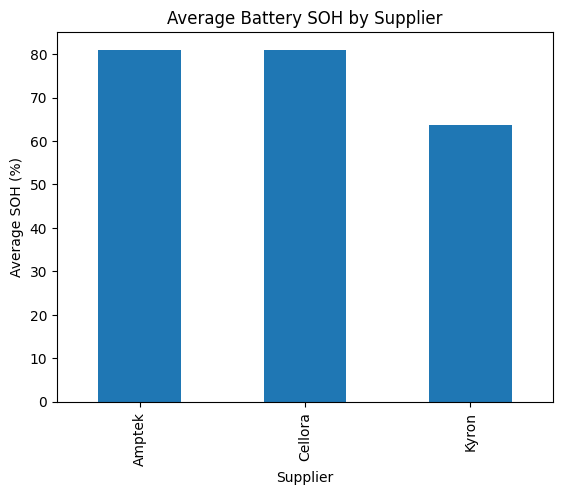

In [67]:
battery_soh.plot(kind="bar")
plt.title("Average Battery SOH by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Average SOH (%)")
plt.show()

In [68]:
batteries["soh_drop"] = (
batteries["initial_soh_pct"] - batteries["current_soh_pct"])
supplier_drop = batteries.groupby("supplier")["soh_drop"].mean()
supplier_drop.sort_values(ascending=False)

,soh_drop
supplier,
Kyron,35.457692
Cellora,18.254740
Amptek,18.189212


# RIDER RETENTION/REPEAT USAGE

Number of swaps made by each rider

In [69]:
rider_swaps = swaps["rider_id"].value_counts()
rider_swaps.head(10)

,count
rider_id,
RD-1001634,933
RD-1002008,892
RD-1002095,887
RD-1000594,885
RD-1002128,868
RD-1003179,863
RD-1000561,859
RD-1004939,847
RD-1004036,835


In [70]:
one_time = (rider_swaps == 1).sum()
repeat = (rider_swaps > 1).sum()
print("One-time riders:", one_time)
print("Repeat riders:", repeat)

One-time riders: 82
Repeat riders: 19868


In [71]:
total_riders = len(rider_swaps)
repeat_percentage = repeat / total_riders * 100
print("Repeat rider percentage:", round(repeat_percentage, 2), "%")

Repeat rider percentage: 99.59 %


In [72]:
average_swaps = rider_swaps.mean()
print("Average swaps per rider:", round(average_swaps, 2))

Average swaps per rider: 193.8


In [73]:
rider_swaps.describe()

,count
count,19950.000000
mean,193.803108
std,163.652504
min,1.000000
25%,59.000000
50%,151.000000
75%,290.000000
max,933.000000


In [74]:
swaps["event_ts"] = pd.to_datetime(swaps["event_ts"])

print("Start date:", swaps["event_ts"].min())
print("End date:", swaps["event_ts"].max())

Start date: 2024-01-01 00:00:33
End date: 2025-06-30 23:59:23


/tmp/ipykernel_15142/3715962644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["event_ts"] = pd.to_datetime(swaps["event_ts"])


In [75]:
completed = swaps[
    swaps["event_type"] == "swap_completed"]
last_swap = completed.groupby("rider_id")["event_ts"].max()
last_swap.head()

,event_ts
rider_id,
RD-1000000,2024-08-10 17:38:38
RD-1000001,2024-10-05 12:50:21
RD-1000002,2025-06-30 08:45:06
RD-1000003,2024-05-05 19:39:08
RD-1000004,2025-03-08 18:40:29


In [76]:
end_date = completed["event_ts"].max()
cutoff_date = end_date - pd.Timedelta(days=60)
print("Dataset end:", end_date)
print("Churn cutoff:", cutoff_date)

Dataset end: 2025-06-30 23:59:23
Churn cutoff: 2025-05-01 23:59:23


In [77]:
rider_status = last_swap.apply(
    lambda x: "Retained" if x >= cutoff_date else "Churned")
rider_status.value_counts()

,count
event_ts,
Retained,13181
Churned,6767


In [78]:
status_percent = rider_status.value_counts(normalize=True) * 100
status_percent.round(2)

,proportion
event_ts,
Retained,66.08
Churned,33.92


In [79]:
swaps["event_type"].value_counts()

,count
event_type,
swap_completed,3645774
failed_no_charged_battery,134095
abandoned_queue,68376
cancelled_by_rider,10663
failed_system_error,7464


In [80]:

swaps["is_failure"] = swaps["event_type"] != "swap_completed"
rider_failures = swaps.groupby("rider_id")["is_failure"].sum()
rider_analysis = rider_status.to_frame("status").join(rider_failures)
rider_analysis.groupby("status")["is_failure"].mean()

/tmp/ipykernel_15142/594129579.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  swaps["is_failure"] = swaps["event_type"] != "swap_completed"


,is_failure
status,
Churned,7.526821
Retained,12.871709


In [81]:
failure_by_status = swaps[
    swaps["event_type"] != "swap_completed"
].merge(rider_status.rename("status"),on="rider_id")
failure_by_status.groupby(
    ["status", "event_type"]
).size()

status    event_type               
Churned   abandoned_queue               15858
          cancelled_by_rider             2819
          failed_no_charged_battery     30347
          failed_system_error            1910
Retained  abandoned_queue               52517
          cancelled_by_rider             7844
          failed_no_charged_battery    103747
          failed_system_error            5554
dtype: int64

In [82]:
rider_analysis["failure_count"] = rider_analysis["is_failure"]
rider_analysis.groupby("status")["failure_count"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Churned,6767.0,7.526821,7.570741,0.0,2.0,5.0,11.0,49.0
Retained,13181.0,12.871709,11.309557,0.0,4.0,10.0,18.0,80.0


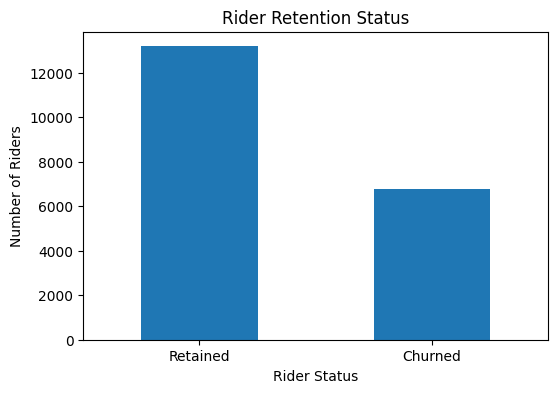

In [83]:
status_counts = rider_status.value_counts()
plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.title("Rider Retention Status")
plt.xlabel("Rider Status")
plt.ylabel("Number of Riders")
plt.xticks(rotation=0)
plt.show()

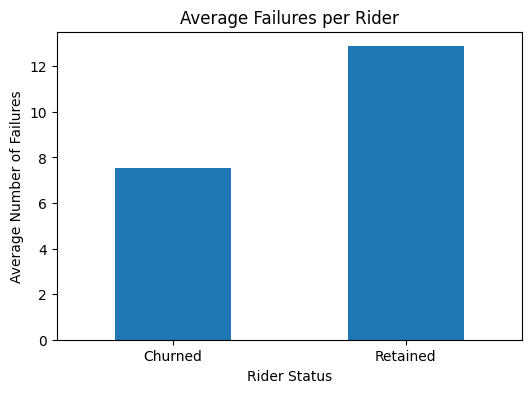

In [84]:
failure_by_status = rider_analysis.groupby("status")["failure_count"].mean()
plt.figure(figsize=(6,4))
failure_by_status.plot(kind="bar")
plt.title("Average Failures per Rider")
plt.xlabel("Rider Status")
plt.ylabel("Average Number of Failures")
plt.xticks(rotation=0)
plt.show()

# SUPPORT TICKETS

In [85]:
print(tickets["category"].value_counts())

category
no_battery_available    11647
other                    9484
low_range                6636
app_issue                5787
long_queue               5731
billing_dispute          4715
Name: count, dtype: int64


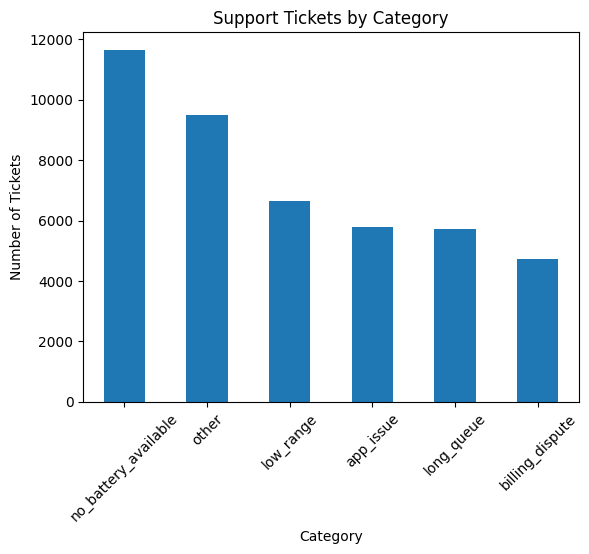

In [86]:
tickets["category"].value_counts().plot(kind="bar")
plt.title("Support Tickets by Category")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [87]:
print(tickets["resolution_status"].value_counts())

resolution_status
resolved      37888
unresolved     5175
duplicate       937
Name: count, dtype: int64


In [88]:
average_resolution = tickets["resolution_hours"].mean()
print("Average resolution time:",round(average_resolution, 2),"hours")

Average resolution time: 15.95 hours


In [89]:
category_resolution = tickets.groupby("category")["resolution_hours"].mean()
print(category_resolution.sort_values(ascending=False))

category
other                   16.036723
low_range               15.990958
no_battery_available    15.961265
billing_dispute         15.908325
app_issue               15.894224
long_queue              15.842201
Name: resolution_hours, dtype: float64


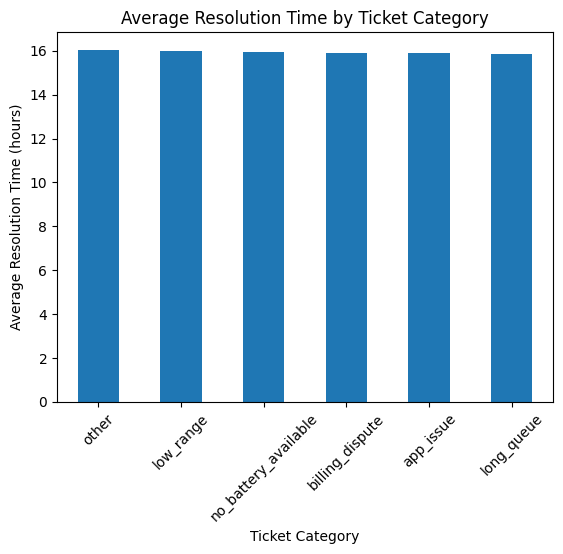

In [90]:
category_resolution.sort_values(ascending=False).plot(kind="bar")
plt.title("Average Resolution Time by Ticket Category")
plt.xlabel("Ticket Category")
plt.ylabel("Average Resolution Time (hours)")
plt.xticks(rotation=45)
plt.show()

In [91]:
print(tickets["csat_score"].describe())

count    15129.000000
mean         3.559720
std          1.305327
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: csat_score, dtype: float64


In [92]:
category_csat = tickets.groupby(
    "category")["csat_score"].mean()
print(category_csat.sort_values())

category
long_queue              3.506520
low_range               3.531183
app_issue               3.539805
other                   3.567468
billing_dispute         3.569136
no_battery_available    3.602452
Name: csat_score, dtype: float64


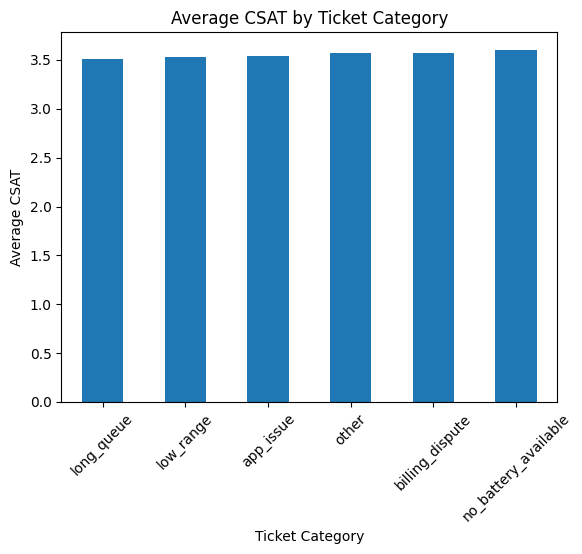

In [93]:
category_csat.sort_values().plot(kind="bar")
plt.title("Average CSAT by Ticket Category")
plt.xlabel("Ticket Category")
plt.ylabel("Average CSAT")
plt.xticks(rotation=45)
plt.show()

In [94]:
ticket_station = tickets["station_id"].value_counts()

print(ticket_station.head(10))

station_id
STN-HYD-072    689
STN-DEL-043    681
STN-JAI-138    674
STN-JAI-141    645
STN-DEL-050    639
STN-JAI-140    626
STN-HYD-070    618
STN-JAI-137    586
STN-JAI-134    584
STN-HYD-065    551
Name: count, dtype: int64


In [95]:
csat_status = tickets.groupby("resolution_status")["csat_score"].mean()
print(csat_status.sort_values())

resolution_status
resolved      3.55972
duplicate         NaN
unresolved        NaN
Name: csat_score, dtype: float64


In [96]:
resolution_category = pd.crosstab(
    tickets["category"],
    tickets["resolution_status"])
print(resolution_category)

resolution_status     duplicate  resolved  unresolved
category                                             
app_issue                   117      4986         684
billing_dispute              98      4084         533
long_queue                   94      4962         675
low_range                   148      5718         770
no_battery_available        263      9996        1388
other                       217      8142        1125


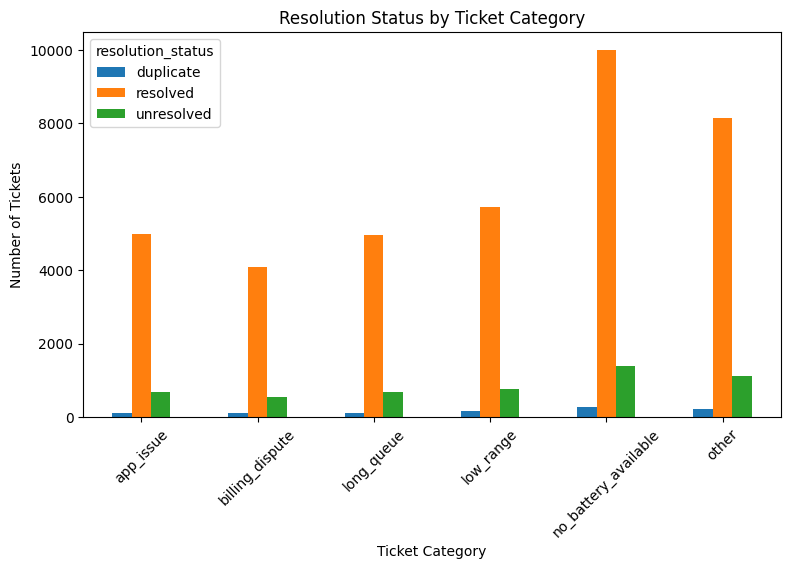

In [97]:
resolution_category.plot(kind="bar", figsize=(9,5))
plt.title("Resolution Status by Ticket Category")
plt.xlabel("Ticket Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [98]:
ticket_riders = tickets.merge( rider_status.rename("status"),on="rider_id", how="left")
print(ticket_riders["status"].value_counts())

status
Retained    34985
Churned      9015
Name: count, dtype: int64


In [99]:
csat_rider_status = ticket_riders.groupby("status")["csat_score"].mean()
print(csat_rider_status)

status
Churned     3.527111
Retained    3.567930
Name: csat_score, dtype: float64


In [100]:
ticket_status = pd.crosstab(
    ticket_riders["status"],
    ticket_riders["category"],
    normalize="index") * 100
print(ticket_status.round(2))

category  app_issue  billing_dispute  long_queue  low_range  \
status                                                        
Churned       10.84            16.64       14.63      12.05   
Retained      13.75             9.19       12.61      15.86   

category  no_battery_available  other  
status                                 
Churned                  28.96  16.88  
Retained                 25.83  22.76  


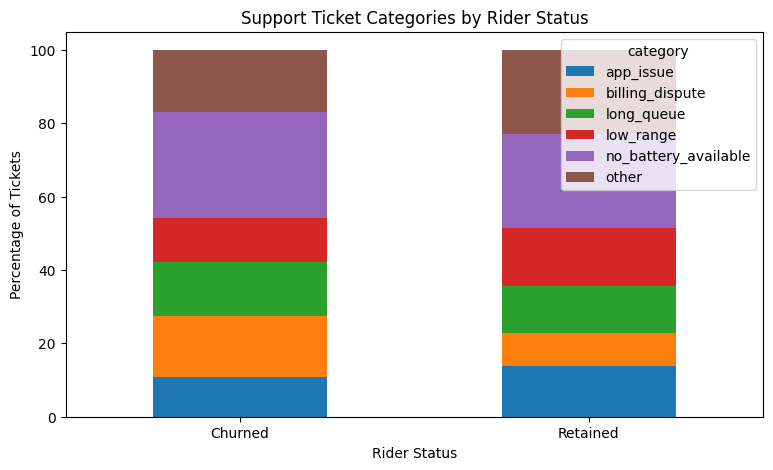

In [101]:
ticket_status.plot(kind="bar",stacked=True,figsize=(9,5))
plt.title("Support Ticket Categories by Rider Status")
plt.xlabel("Rider Status")
plt.ylabel("Percentage of Tickets")
plt.xticks(rotation=0)
plt.show()